#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Import Multi-task ElasticNet

In [3]:
import joblib

model_1 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/ElasticNet.pkl')

In [4]:
model_features = model_1.feature_names_in_
model_features

array(['GPT', 'GUSB', 'NDUFA7', ..., 'UGT2B11', 'NAA60', 'MTAP'],
      dtype=object)

In [5]:
import pickle

with open('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/y_train_features.pkl', 'rb') as f:
    y_train_features_loaded = pickle.load(f)

print(y_train_features_loaded)

Index(['2-aminoadipate', '3-phosphoglycerate', 'alpha-glycerophosphate',
       '4-pyridoxate', 'aconitate', 'adenine', 'adipate',
       'alpha-ketoglutarate', 'AMP', 'citrate',
       ...
       'C56:8 TAG', 'C56:7 TAG', 'C56:6 TAG', 'C56:5 TAG', 'C56:4 TAG',
       'C56:3 TAG', 'C56:2 TAG', 'C58:8 TAG', 'C58:7 TAG', 'C58:6 TAG'],
      dtype='object', length=225)


#Import Random forest regressor

In [6]:
model_2 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/Random Forest Regressor.pkl')

#Import ensemble

In [7]:
final_estimator = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/Ensemble.pkl')

#RNA-Seq data

In [8]:
counts_mcf7 = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/MCF7_isogenics_RNA_seq/RawCounts.csv')
counts_mcf7 = counts_mcf7.rename(columns = {'Gene_ID' : 'gene_id'})

counts_mcf7 = counts_mcf7[['gene_id', 'eV_DM1', 'eV_DM2', 'eV_DM3',
                           'PI3K_WT_DM1', 'PI3K_WT_DM2', 'PI3K_WT_DM3']]

counts_mcf7 = counts_mcf7.rename(columns = {'eV_DM1' : 'MCF7_E545K_1',
                                            'eV_DM2' : 'MCF7_E545K_2',
                                            'eV_DM3' : 'MCF7_E545K_3',
                                            'PI3K_WT_DM1' : 'MCF7_WT_1',
                                            'PI3K_WT_DM2' : 'MCF7_WT_2',
                                            'PI3K_WT_DM3' : 'MCF7_WT_3'})

counts_mcf7 = counts_mcf7.set_index('gene_id')
counts_mcf7

,MCF7_E545K_1,MCF7_E545K_2,MCF7_E545K_3,MCF7_WT_1,MCF7_WT_2,MCF7_WT_3
gene_id,,,,,,
ENSG00000223972,0,9,3,2,5,10
ENSG00000227232,1407,1327,1275,1152,1341,1502
ENSG00000278267,50,62,18,33,67,87
ENSG00000243485,2,5,2,8,8,6
ENSG00000284332,0,0,0,0,0,0
...,...,...,...,...,...,...
ENSG00000271254,7058,8025,9493,5142,6120,6805
ENSG00000275405,5,3,7,4,8,13
ENSG00000275987,0,0,0,0,4,0


In [9]:
counts_mcf10a = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/MCF10A_PIK3CA_isogenics_RNA_seq_analysis/MCF_PI3K_featureCounts/counts_matrix_filtered_MCF_PI3K.csv')
counts_mcf10a = counts_mcf10a.rename(columns = {'Unnamed: 0' : 'gene_id'})


# #compare by excluding E5_3

counts_mcf10a = counts_mcf10a[['gene_id', 'MCF_WT_1', 'MCF_WT_2', 'MCF_WT_3',
                               'MCF_E5_1', 'MCF_E5_2',
                               'MCF_H10_1', 'MCF_H10_2', 'MCF_H10_3']]


counts_mcf10a = counts_mcf10a.rename(columns = {'MCF_WT_1' : 'MCF10A_WT_1', 'MCF_WT_2' : 'MCF10A_WT_2', 'MCF_WT_3' : 'MCF10A_WT_3',
                                                'MCF_E5_1' : 'MCF10A_E545K_1', 'MCF_E5_2' : 'MCF10A_E545K_2',
                                                'MCF_H10_1' : 'MCF10A_H1047R_1', 'MCF_H10_2' : 'MCF10A_H1047R_2', 'MCF_H10_3' : 'MCF10A_H1047R_3'})
counts_mcf10a = counts_mcf10a.set_index('gene_id')
counts_mcf10a

,MCF10A_WT_1,MCF10A_WT_2,MCF10A_WT_3,MCF10A_E545K_1,MCF10A_E545K_2,MCF10A_H1047R_1,MCF10A_H1047R_2,MCF10A_H1047R_3
gene_id,,,,,,,,
ENSG00000227232,418,506,525,255,329,328,249,372
ENSG00000233750,13,39,25,14,5,17,3,13
ENSG00000268903,8,8,12,9,17,11,27,12
ENSG00000241860,5,22,13,31,19,28,11,19
ENSG00000279457,465,501,370,168,212,339,240,323
...,...,...,...,...,...,...,...,...
ENSG00000182484,81,153,117,59,105,34,31,42
ENSG00000231341,20,22,20,34,24,26,20,20
ENSG00000235001,34,44,72,92,55,77,68,69


#TPM normalization

In [10]:
#TMM normalization with rnanorm
!pip install rnanorm
from rnanorm import TPM

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.6/124.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.2/264.2 kB 10.2 MB/s eta 0:00:00


In [11]:
def tpm_normalize(counts):
  counts = counts.T
  norm_counts = TPM(gtf = 'drive/My Drive/Colab Notebooks/Homo_sapiens.GRCh38.113.gtf').fit(counts)
  norm_counts = norm_counts.transform(counts)
  norm_counts = pd.DataFrame(norm_counts)
  norm_counts.columns = counts.columns
  norm_counts.index = counts.index

  return norm_counts

In [12]:
mcf7_tpm = tpm_normalize(counts_mcf7)
mcf10a_tpm = tpm_normalize(counts_mcf10a)

/usr/local/lib/python3.11/dist-packages/rnanorm/methods/within_sample.py:138: UserWarning: X contains 1379 genes that are not in GTF drive/My Drive/Colab Notebooks/Homo_sapiens.GRCh38.113.gtf. This will result in NaN values for missing genes in the output.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/rnanorm/methods/within_sample.py:138: UserWarning: X contains 164 genes that are not in GTF drive/My Drive/Colab Notebooks/Homo_sapiens.GRCh38.113.gtf. This will result in NaN values for missing genes in the output.
  warnings.warn(


In [13]:
mcf7_tpm.head(3)

gene_id,ENSG00000223972,ENSG00000227232,ENSG00000278267,ENSG00000243485,ENSG00000284332,ENSG00000237613,ENSG00000268020,ENSG00000240361,ENSG00000186092,ENSG00000238009,...,ENSG00000273532,ENSG00000276351,ENSG00000275661,ENSG00000277856,ENSG00000275063,ENSG00000271254,ENSG00000275405,ENSG00000275987,ENSG00000277475,ENSG00000268674
MCF7_E545K_1,0.000000,30.198648,21.778782,0.033986,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,48.707342,0.903023,0.0,0.0,0.0
MCF7_E545K_2,0.419595,28.333248,26.865029,0.084523,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,55.092167,0.538992,0.0,0.0,0.0
MCF7_E545K_3,0.116541,22.683291,6.498881,0.028171,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,54.302364,1.047922,0.0,0.0,0.0


In [14]:
mcf10a_tpm.head(3)

gene_id,ENSG00000227232,ENSG00000233750,ENSG00000268903,ENSG00000241860,ENSG00000279457,ENSG00000228463,ENSG00000236679,ENSG00000236601,ENSG00000237094,ENSG00000250575,...,ENSG00000274791,ENSG00000277150,ENSG00000185973,ENSG00000124333,ENSG00000185203,ENSG00000182484,ENSG00000231341,ENSG00000235001,ENSG00000215414,ENSG00000185275
MCF10A_WT_1,10.088677,0.113587,0.352923,0.011417,11.086477,10.349257,0.692096,2.690787,10.920365,0.806468,...,NaN,23.414492,2.091877,14.443697,1.456343,0.584209,0.779114,0.928231,33.262165,27.824462
MCF10A_WT_2,11.164092,0.311504,0.322623,0.045924,10.919262,34.445009,2.926126,2.112878,9.650034,0.786377,...,NaN,15.446722,1.852706,11.340683,3.007771,1.008764,0.783445,1.098107,37.802592,17.917678
MCF10A_WT_3,12.287037,0.211814,0.513335,0.028786,8.554059,45.795810,6.795028,6.272143,3.000301,0.443144,...,NaN,18.807012,2.268587,16.204256,3.216660,0.818274,0.755494,1.906073,42.975966,34.955572


#Select genes in metabolism

In [15]:
met_genes = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/FBA_metabolic_atlas_models/human_gem_associated_genes.csv')
met_genes

,gene_id,Symbol
0,ENSG00000198712,MT-CO2
1,ENSG00000198804,MT-CO1
2,ENSG00000198938,MT-CO3
3,ENSG00000198899,MT-ATP6
4,ENSG00000198886,MT-ND4
...,...,...
2879,ENSG00000167751,KLK2
2880,ENSG00000129873,CDY2B
2881,ENSG00000182415,CDY2A
2882,ENSG00000172352,CDY1B


In [16]:
def select_met_genes(df):
  met_genes_select = met_genes[met_genes['gene_id'].isin(df.columns)]
  met_genes_select = met_genes_select.gene_id.to_list()
  print('N of metabolism related genes: ' + str(len(met_genes_select)))
  df = df[met_genes_select]
  df = df.T
  df = pd.concat([met_genes.set_index('gene_id'), df], axis = 'columns')
  df = df.set_index('Symbol')
  df.index.name = None
  df = df.T

  return df

In [17]:
mcf7_met = select_met_genes(mcf7_tpm)
mcf10a_met = select_met_genes(mcf10a_tpm)

N of metabolism related genes: 2884
N of metabolism related genes: 2173


In [18]:
mcf7_met.head(3)

,MT-CO2,MT-CO1,MT-CO3,MT-ATP6,MT-ND4,MT-ND4L,MT-ND2,MT-ND3,EEF1A1,MT-ND1,...,HS3ST4,COX6A2,ENPP7,TGM6,CYP2A13,KLK2,CDY2B,CDY2A,CDY1B,CDY1
MCF7_E545K_1,34493.310622,41953.268546,16042.959405,16042.571568,24442.499110,8039.153966,8620.932950,2442.808849,1811.556581,8677.138592,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
MCF7_E545K_2,34702.983113,43156.748151,18071.999984,16606.980586,27328.453225,9084.207958,8857.501910,2621.436697,1635.167067,8670.716098,...,0.0,0.0,0.050196,0.0,0.0,0.009279,0.0,0.0,0.0,0.0
MCF7_E545K_3,37164.140400,46634.481240,18255.602600,16691.261066,27806.034684,10241.209901,9497.240214,2517.078670,1810.959841,9240.698279,...,0.0,0.0,0.125475,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [19]:
mcf10a_met.head(3)

,MT-CO2,MT-CO1,MT-CO3,MT-ATP6,MT-ND4,MT-ND4L,MT-ND2,MT-ND3,EEF1A1,MT-ND1,...,HS3ST4,COX6A2,ENPP7,TGM6,CYP2A13,KLK2,CDY2B,CDY2A,CDY1B,CDY1
MCF10A_WT_1,81191.934371,4136.022153,26445.084021,6663.281399,2370.219332,1423.346445,1319.274978,173.370268,381.610229,862.814524,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MCF10A_WT_2,116934.644288,11382.042072,43101.730088,15083.774097,4936.166461,3618.436862,2537.809752,233.812332,314.490258,1476.895926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MCF10A_WT_3,60088.613131,6961.022300,23361.162199,7570.101378,2399.473081,1484.155846,1134.436808,156.726177,427.054916,740.001297,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Metabolite prediction

In [20]:
def filter_model_features(df):
  filtered_data = df[model_features]
  return filtered_data

In [21]:
mcf7_met_filtered = filter_model_features(mcf7_met)
mcf10a_met_filtered = filter_model_features(mcf10a_met)

In [22]:
mcf7_met_filtered.head(2)

,GPT,GUSB,NDUFA7,MAN2B2,CYB5R4,NT5M,CERS2,TENT2,GLYATL2,SLC5A2,...,FABP5,CYP4A22,THEM5,PDE6G,ACER1,ENOPH1,ATP2B4,UGT2B11,NAA60,MTAP
MCF7_E545K_1,3.288628,26.347570,0.595787,26.598550,8.854033,8.851003,156.848130,16.458838,0.336964,0.245279,...,39.450707,0.000000,3.852274,0.270494,0.746701,169.965250,23.057546,0.025133,47.687263,0.024467
MCF7_E545K_2,4.479601,35.413852,0.656186,38.393217,7.886087,8.865004,188.700821,15.199397,0.234646,0.230813,...,28.505405,0.030677,4.136756,0.322903,1.403089,147.946748,31.771949,0.075006,44.732556,0.068962


In [23]:
mcf10a_met_filtered.head(2)

,GPT,GUSB,NDUFA7,MAN2B2,CYB5R4,NT5M,CERS2,TENT2,GLYATL2,SLC5A2,...,FABP5,CYP4A22,THEM5,PDE6G,ACER1,ENOPH1,ATP2B4,UGT2B11,NAA60,MTAP
MCF10A_WT_1,NaN,23.468126,0.191420,1.192218,2.918397,1.613552,21.391733,2.986417,NaN,NaN,...,20.117217,NaN,NaN,NaN,0.559783,80.605455,0.462696,NaN,6.476509,1.160143
MCF10A_WT_2,NaN,15.908107,0.262479,0.712864,1.984263,0.931592,14.584383,2.886516,NaN,NaN,...,12.457258,NaN,NaN,NaN,0.469079,57.562335,0.390928,NaN,4.308807,0.907536


In [24]:
def predict_metabolites(model, filtered_data):
  pred_metabolites = model.predict(filtered_data)
  pred_metabolites = pd.DataFrame(pred_metabolites, index = filtered_data.index, columns = y_train_features_loaded)
  return pred_metabolites

In [25]:
#Elastic Net predictions
mcf7_pred_elastic = predict_metabolites(model_1, mcf7_met_filtered)
mcf10a_pred_elastic = predict_metabolites(model_1, mcf10a_met_filtered)

#Random forest regressor predictions
mcf7_pred_rf = predict_metabolites(model_2, mcf7_met_filtered)
mcf10a_pred_rf = predict_metabolites(model_2, mcf10a_met_filtered)

In [26]:
#Ensemble predictions

def predict_metabolites_ensemble(model_1, model_2, final_estimator, filtered_data):
  pred_1 = model_1.predict(filtered_data)
  pred_2 = model_2.predict(filtered_data)
  stacked_preds = np.hstack([pred_1, pred_2])
  pred_metabolites = final_estimator.predict(stacked_preds)
  pred_metabolites = pd.DataFrame(pred_metabolites, index = filtered_data.index, columns = y_train_features_loaded)

  return pred_metabolites

mcf7_pred_ensemble = predict_metabolites_ensemble(model_1, model_2, final_estimator, mcf7_met_filtered)
mcf10a_pred_ensemble = predict_metabolites_ensemble(model_1, model_2, final_estimator, mcf10a_met_filtered)

#LCMS data

In [27]:
lcms = pd.read_excel('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/MCF10A_MCF7_LCMS_normalized.xlsx', index_col = 0)
lcms

,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,acetylcholine,glutathione oxidized
MCF7_WT_1,35541.894005,3310.080096,150945.293046,42114.200959,103924.517026,43336.885851,3967.657554,4.784093e+05,201953.260911,6.822255e+05,...,1.314340e+06,3.967905e+06,2.150769e+06,1.771171e+05,91857.178897,248280.974101,88877.101199,3.035166e+06,115.703118,192210.272422
MCF7_WT_2,14250.859512,2676.598618,85987.312483,14393.194933,66969.581760,21969.409028,3789.039521,2.249900e+05,135821.694334,4.541660e+05,...,5.323872e+05,1.478587e+06,8.449855e+05,6.687347e+04,49795.817411,140994.724367,24071.870382,1.596358e+06,NaN,84854.357163
MCF7_WT_3,12887.727142,1451.936150,91137.651176,13016.132403,66898.795217,26185.682583,2209.803826,2.146673e+05,90900.320446,3.625452e+05,...,5.480853e+01,1.612582e+06,8.899339e+05,8.128745e+04,57107.490634,156653.208210,37291.354484,1.939672e+06,NaN,122525.706337
MCF7_WT_4,28632.511243,2745.688757,120872.221194,21729.591931,89713.526950,30158.084024,1805.905433,2.916907e+05,163540.966541,6.532584e+05,...,7.970991e+05,1.921981e+06,1.116434e+06,1.158219e+05,69204.128779,189889.902313,49227.704895,2.481447e+06,NaN,176976.865627
MCF7_WT_5,16004.619583,2177.411052,98718.132622,13144.301212,67084.306738,25022.178381,1645.271837,2.004729e+05,182829.282113,5.553383e+05,...,4.767651e+05,1.341003e+06,7.703748e+05,5.125723e+04,44879.410179,129103.828502,19297.055744,1.514886e+06,NaN,85932.702957
MCF7_MUT_1,43495.939566,3973.417651,303369.826627,125137.618699,141189.192072,88240.608826,6250.570232,1.026626e+06,662120.047270,1.864743e+05,...,2.682803e+06,5.848008e+06,3.033033e+06,1.879675e+06,135979.374121,366407.964099,201496.801346,1.090204e+07,NaN,658458.757966
MCF7_MUT_2,33506.231755,4507.138820,239993.873270,180537.681282,132609.784851,59242.820102,24731.233940,9.600431e+05,590011.811799,4.797811e+05,...,2.394286e+06,2.876707e+06,1.352517e+06,1.719942e+06,96026.300801,256525.139257,185627.643409,8.016369e+06,89.624618,416896.544355
MCF7_MUT_3,64247.939956,3386.129801,286529.102870,96537.683885,166325.112583,63800.307726,7042.839294,9.320464e+05,535414.856954,6.176914e+05,...,2.209929e+06,6.629485e+06,3.395400e+06,1.505575e+06,100836.315232,267868.680353,144392.303753,8.148592e+06,NaN,650954.087417
MCF7_MUT_4,37351.437802,3660.772662,211585.737214,127766.819882,135736.464487,49759.233748,13615.002616,7.163067e+05,113657.869719,7.765933e+05,...,1.744811e+06,6.252571e+06,3.153422e+06,1.140437e+06,84101.781033,221962.702289,124926.550556,6.331661e+06,NaN,336237.178940
MCF7_MUT_5,24899.654572,2692.923775,204265.746891,108526.795611,146907.993709,44616.874762,11123.304755,7.394418e+05,163103.511046,1.038318e+06,...,6.061141e+01,6.917212e+06,2.156535e+06,1.001172e+06,83208.573226,235432.282955,118338.122458,5.869986e+06,79.757425,259971.019312


In [28]:
mcf7_lcms = lcms.iloc[0:10, :]
mcf7_lcms

,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,acetylcholine,glutathione oxidized
MCF7_WT_1,35541.894005,3310.080096,150945.293046,42114.200959,103924.517026,43336.885851,3967.657554,4.784093e+05,201953.260911,6.822255e+05,...,1.314340e+06,3.967905e+06,2.150769e+06,1.771171e+05,91857.178897,248280.974101,88877.101199,3.035166e+06,115.703118,192210.272422
MCF7_WT_2,14250.859512,2676.598618,85987.312483,14393.194933,66969.581760,21969.409028,3789.039521,2.249900e+05,135821.694334,4.541660e+05,...,5.323872e+05,1.478587e+06,8.449855e+05,6.687347e+04,49795.817411,140994.724367,24071.870382,1.596358e+06,NaN,84854.357163
MCF7_WT_3,12887.727142,1451.936150,91137.651176,13016.132403,66898.795217,26185.682583,2209.803826,2.146673e+05,90900.320446,3.625452e+05,...,5.480853e+01,1.612582e+06,8.899339e+05,8.128745e+04,57107.490634,156653.208210,37291.354484,1.939672e+06,NaN,122525.706337
MCF7_WT_4,28632.511243,2745.688757,120872.221194,21729.591931,89713.526950,30158.084024,1805.905433,2.916907e+05,163540.966541,6.532584e+05,...,7.970991e+05,1.921981e+06,1.116434e+06,1.158219e+05,69204.128779,189889.902313,49227.704895,2.481447e+06,NaN,176976.865627
MCF7_WT_5,16004.619583,2177.411052,98718.132622,13144.301212,67084.306738,25022.178381,1645.271837,2.004729e+05,182829.282113,5.553383e+05,...,4.767651e+05,1.341003e+06,7.703748e+05,5.125723e+04,44879.410179,129103.828502,19297.055744,1.514886e+06,NaN,85932.702957
MCF7_MUT_1,43495.939566,3973.417651,303369.826627,125137.618699,141189.192072,88240.608826,6250.570232,1.026626e+06,662120.047270,1.864743e+05,...,2.682803e+06,5.848008e+06,3.033033e+06,1.879675e+06,135979.374121,366407.964099,201496.801346,1.090204e+07,NaN,658458.757966
MCF7_MUT_2,33506.231755,4507.138820,239993.873270,180537.681282,132609.784851,59242.820102,24731.233940,9.600431e+05,590011.811799,4.797811e+05,...,2.394286e+06,2.876707e+06,1.352517e+06,1.719942e+06,96026.300801,256525.139257,185627.643409,8.016369e+06,89.624618,416896.544355
MCF7_MUT_3,64247.939956,3386.129801,286529.102870,96537.683885,166325.112583,63800.307726,7042.839294,9.320464e+05,535414.856954,6.176914e+05,...,2.209929e+06,6.629485e+06,3.395400e+06,1.505575e+06,100836.315232,267868.680353,144392.303753,8.148592e+06,NaN,650954.087417
MCF7_MUT_4,37351.437802,3660.772662,211585.737214,127766.819882,135736.464487,49759.233748,13615.002616,7.163067e+05,113657.869719,7.765933e+05,...,1.744811e+06,6.252571e+06,3.153422e+06,1.140437e+06,84101.781033,221962.702289,124926.550556,6.331661e+06,NaN,336237.178940
MCF7_MUT_5,24899.654572,2692.923775,204265.746891,108526.795611,146907.993709,44616.874762,11123.304755,7.394418e+05,163103.511046,1.038318e+06,...,6.061141e+01,6.917212e+06,2.156535e+06,1.001172e+06,83208.573226,235432.282955,118338.122458,5.869986e+06,79.757425,259971.019312


In [29]:
mcf7_lcms.drop(columns = ['acetylcholine', 'lactate', 'kynurenic acid'], inplace = True)
mcf7_lcms

<ipython-input-29-b689c9715496>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf7_lcms.drop(columns = ['acetylcholine', 'lactate', 'kynurenic acid'], inplace = True)


,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,NAD,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,glutathione oxidized
MCF7_WT_1,35541.894005,3310.080096,150945.293046,42114.200959,103924.517026,43336.885851,3967.657554,4.784093e+05,201953.260911,6.822255e+05,...,19620.520863,1.314340e+06,3.967905e+06,2.150769e+06,1.771171e+05,91857.178897,248280.974101,88877.101199,3.035166e+06,192210.272422
MCF7_WT_2,14250.859512,2676.598618,85987.312483,14393.194933,66969.581760,21969.409028,3789.039521,2.249900e+05,135821.694334,4.541660e+05,...,7167.391064,5.323872e+05,1.478587e+06,8.449855e+05,6.687347e+04,49795.817411,140994.724367,24071.870382,1.596358e+06,84854.357163
MCF7_WT_3,12887.727142,1451.936150,91137.651176,13016.132403,66898.795217,26185.682583,2209.803826,2.146673e+05,90900.320446,3.625452e+05,...,10013.881387,5.480853e+01,1.612582e+06,8.899339e+05,8.128745e+04,57107.490634,156653.208210,37291.354484,1.939672e+06,122525.706337
MCF7_WT_4,28632.511243,2745.688757,120872.221194,21729.591931,89713.526950,30158.084024,1805.905433,2.916907e+05,163540.966541,6.532584e+05,...,12885.656805,7.970991e+05,1.921981e+06,1.116434e+06,1.158219e+05,69204.128779,189889.902313,49227.704895,2.481447e+06,176976.865627
MCF7_WT_5,16004.619583,2177.411052,98718.132622,13144.301212,67084.306738,25022.178381,1645.271837,2.004729e+05,182829.282113,5.553383e+05,...,5611.293068,4.767651e+05,1.341003e+06,7.703748e+05,5.125723e+04,44879.410179,129103.828502,19297.055744,1.514886e+06,85932.702957
MCF7_MUT_1,43495.939566,3973.417651,303369.826627,125137.618699,141189.192072,88240.608826,6250.570232,1.026626e+06,662120.047270,1.864743e+05,...,40261.961107,2.682803e+06,5.848008e+06,3.033033e+06,1.879675e+06,135979.374121,366407.964099,201496.801346,1.090204e+07,658458.757966
MCF7_MUT_2,33506.231755,4507.138820,239993.873270,180537.681282,132609.784851,59242.820102,24731.233940,9.600431e+05,590011.811799,4.797811e+05,...,21431.341879,2.394286e+06,2.876707e+06,1.352517e+06,1.719942e+06,96026.300801,256525.139257,185627.643409,8.016369e+06,416896.544355
MCF7_MUT_3,64247.939956,3386.129801,286529.102870,96537.683885,166325.112583,63800.307726,7042.839294,9.320464e+05,535414.856954,6.176914e+05,...,29363.269757,2.209929e+06,6.629485e+06,3.395400e+06,1.505575e+06,100836.315232,267868.680353,144392.303753,8.148592e+06,650954.087417
MCF7_MUT_4,37351.437802,3660.772662,211585.737214,127766.819882,135736.464487,49759.233748,13615.002616,7.163067e+05,113657.869719,7.765933e+05,...,25968.230739,1.744811e+06,6.252571e+06,3.153422e+06,1.140437e+06,84101.781033,221962.702289,124926.550556,6.331661e+06,336237.178940
MCF7_MUT_5,24899.654572,2692.923775,204265.746891,108526.795611,146907.993709,44616.874762,11123.304755,7.394418e+05,163103.511046,1.038318e+06,...,22088.152451,6.061141e+01,6.917212e+06,2.156535e+06,1.001172e+06,83208.573226,235432.282955,118338.122458,5.869986e+06,259971.019312


In [30]:
mcf10a_lcms = lcms.iloc[10:, :]
mcf10a_lcms

,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,acetylcholine,glutathione oxidized
MCF10A_WT_1,11830.093342,8652.912605,5515.644085,35109.478216,7526.397285,4152.646542,8230.889981,5.571144e+05,76380.019392,259356.317259,...,551.854169,5.834417e+05,3.455954e+05,852.177246,28489.284551,76488.352553,1905.971946,2.369021e+05,250.409438,4606.729800
MCF10A_WT_2,9176.798313,1505.303829,31346.202206,112189.519273,32145.771707,3180.449319,92632.861908,1.034349e+06,206886.098118,20127.081376,...,711.833615,3.146509e+06,1.711198e+06,155.954056,195616.306295,537734.651525,20201.304997,2.278253e+06,77.038676,100363.847891
MCF10A_WT_3,10487.827077,1485.741894,20739.051249,77446.785357,27374.687275,3195.735619,54184.417897,7.565017e+05,7941.069030,68385.045322,...,448545.839163,2.673478e+06,1.501980e+06,1742.761883,113430.423940,312787.948518,9835.992795,1.246476e+06,66.460546,51375.850668
MCF10A_WT_4,13032.483306,563.422149,20068.567934,89737.644628,21146.495207,3806.126942,31977.075041,6.205438e+05,13173.896529,51342.082314,...,455670.530909,2.676117e+06,1.481157e+06,NaN,128539.919339,352125.378843,15672.648264,1.450346e+06,79.111736,67638.940496
MCF10A_WT_5,32157.281239,1734.868158,14690.546988,49049.182788,23176.816523,6897.162823,18587.280551,4.947511e+05,58112.524957,119484.398623,...,3.816179,2.267925e+06,1.302684e+06,581.718417,86525.885714,233999.883305,7694.827194,9.234633e+05,62.552151,45523.199312
MCF10A_E545K_1,11424.896120,2464.334092,11228.605173,25484.010760,6447.828453,2018.415520,3255.557165,3.386269e+05,41674.273564,196161.083497,...,206412.123849,6.128633e+05,3.655116e+05,669.738127,45127.094154,119918.956855,1140.193068,4.322967e+05,61.714951,22352.407139
MCF10A_E545K_2,10554.987225,1799.926418,14230.280327,43089.396117,10417.406643,1632.051507,8758.681349,3.037884e+05,39372.873173,209387.893306,...,360434.156873,1.986785e+06,1.132701e+06,NaN,88641.721104,233034.241901,5697.919775,1.009606e+06,NaN,87833.823097
MCF10A_E545K_3,7480.199674,3297.336052,10236.091680,24235.007178,6512.582708,2996.341599,2993.039152,2.342253e+05,38886.863622,145619.591191,...,205817.695595,6.660150e+05,3.814336e+05,NaN,44117.310604,117690.089396,1811.706688,4.050945e+05,NaN,20982.647308
MCF10A_E545K_4,4782.328759,1711.945836,13716.775694,71823.403248,15715.421896,1424.033525,30107.174332,3.592066e+05,61236.698690,61905.918701,...,520638.397590,2.431798e+06,1.357720e+06,NaN,114544.636249,306830.216763,10617.003143,1.320114e+06,NaN,214796.823677
MCF10A_E545K_5,5669.114272,2143.611672,13254.125356,47938.410397,10107.887494,3323.956155,9385.383914,2.135255e+05,41367.655910,40018.174105,...,96.801864,1.946320e+06,1.244690e+06,NaN,101527.071113,274325.276704,5333.038058,1.184912e+06,NaN,125587.262972


In [31]:
mcf10a_lcms.drop(columns = ['acetylcholine', 'lactate', 'kynurenic acid', 'allantoin', 'cystathionine', 'glycodeoxycholate/glycochenodeoxycholate',
                            'serotonin', 'guanosine'], inplace = True)
mcf10a_lcms

<ipython-input-31-70316a840654>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf10a_lcms.drop(columns = ['acetylcholine', 'lactate', 'kynurenic acid', 'allantoin', 'cystathionine', 'glycodeoxycholate/glycochenodeoxycholate',


,adenine,xanthine,uracil,uridine,phenylalanine,leucine,methionine,betaine,urate,hypoxanthine,...,NADH,NAD,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,ornithine,arginine,phosphocreatine,lysine,glutathione oxidized
MCF10A_WT_1,11830.093342,5515.644085,35109.478216,7526.397285,5.571144e+05,76380.019392,259356.317259,598140.376988,2159.652877,162651.538720,...,6922.479638,NaN,551.854169,5.834417e+05,3.455954e+05,28489.284551,76488.352553,1905.971946,2.369021e+05,4606.729800
MCF10A_WT_2,9176.798313,31346.202206,112189.519273,32145.771707,1.034349e+06,206886.098118,20127.081376,905087.526541,5833.451136,310966.569500,...,22748.836080,7856.255938,711.833615,3.146509e+06,1.711198e+06,195616.306295,537734.651525,20201.304997,2.278253e+06,100363.847891
MCF10A_WT_3,10487.827077,20739.051249,77446.785357,27374.687275,7.565017e+05,7941.069030,68385.045322,979238.845904,392.209646,226384.953399,...,21153.274375,6339.798373,448545.839163,2.673478e+06,1.501980e+06,113430.423940,312787.948518,9835.992795,1.246476e+06,51375.850668
MCF10A_WT_4,13032.483306,20068.567934,89737.644628,21146.495207,6.205438e+05,13173.896529,51342.082314,998230.126281,2665.579504,228842.207273,...,29176.216860,9903.705785,455670.530909,2.676117e+06,1.481157e+06,128539.919339,352125.378843,15672.648264,1.450346e+06,67638.940496
MCF10A_WT_5,32157.281239,14690.546988,49049.182788,23176.816523,4.947511e+05,58112.524957,119484.398623,902455.319793,2276.018933,234009.672633,...,14684.573838,4256.532874,3.816179,2.267925e+06,1.302684e+06,86525.885714,233999.883305,7694.827194,9.234633e+05,45523.199312
MCF10A_E545K_1,11424.896120,11228.605173,25484.010760,6447.828453,3.386269e+05,41674.273564,196161.083497,489507.430523,1614.687532,120814.683911,...,8375.130264,3244.934713,206412.123849,6.128633e+05,3.655116e+05,45127.094154,119918.956855,1140.193068,4.322967e+05,22352.407139
MCF10A_E545K_2,10554.987225,14230.280327,43089.396117,10417.406643,3.037884e+05,39372.873173,209387.893306,732463.652529,2077.156464,163409.822177,...,20388.747777,6082.214410,360434.156873,1.986785e+06,1.132701e+06,88641.721104,233034.241901,5697.919775,1.009606e+06,87833.823097
MCF10A_E545K_3,7480.199674,10236.091680,24235.007178,6512.582708,2.342253e+05,38886.863622,145619.591191,468535.923654,1478.945840,137430.151713,...,11023.646656,5618.720392,205817.695595,6.660150e+05,3.814336e+05,44117.310604,117690.089396,1811.706688,4.050945e+05,20982.647308
MCF10A_E545K_4,4782.328759,13716.775694,71823.403248,15715.421896,3.592066e+05,61236.698690,61905.918701,727153.633106,4964.423258,213651.688633,...,26168.282452,7764.467051,520638.397590,2.431798e+06,1.357720e+06,114544.636249,306830.216763,10617.003143,1.320114e+06,214796.823677
MCF10A_E545K_5,5669.114272,13254.125356,47938.410397,10107.887494,2.135255e+05,41367.655910,40018.174105,529986.374007,2342.888769,158492.450319,...,21015.790976,6449.060716,96.801864,1.946320e+06,1.244690e+06,101527.071113,274325.276704,5333.038058,1.184912e+06,125587.262972


In [32]:
from sklearn.impute import SimpleImputer

def filter_and_impute_missing_values(df, set_threshold):
  threshold = set_threshold
  nan_percentage = df.isnull().mean()
  filtered_df = df.loc[:, nan_percentage <= threshold]

  imputer = SimpleImputer(missing_values = np.nan, strategy = 'median')
  res = imputer.fit_transform(filtered_df)
  res = pd.DataFrame(res, columns = filtered_df.columns)
  res.index = filtered_df.index

  return res

In [33]:
mcf7_lcms_clean_imputed = filter_and_impute_missing_values(df = mcf7_lcms, set_threshold = 0.2)
mcf10a_lcms_clean_imputed = filter_and_impute_missing_values(df = mcf10a_lcms, set_threshold = 0.2)

In [34]:
mcf7_lcms_clean_imputed

,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,NAD,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,glutathione oxidized
MCF7_WT_1,35541.894005,3310.080096,150945.293046,42114.200959,103924.517026,43336.885851,3967.657554,4.784093e+05,201953.260911,6.822255e+05,...,19620.520863,1.314340e+06,3.967905e+06,2.150769e+06,1.771171e+05,91857.178897,248280.974101,88877.101199,3.035166e+06,192210.272422
MCF7_WT_2,14250.859512,2676.598618,85987.312483,14393.194933,66969.581760,21969.409028,3789.039521,2.249900e+05,135821.694334,4.541660e+05,...,7167.391064,5.323872e+05,1.478587e+06,8.449855e+05,6.687347e+04,49795.817411,140994.724367,24071.870382,1.596358e+06,84854.357163
MCF7_WT_3,12887.727142,1451.936150,91137.651176,13016.132403,66898.795217,26185.682583,2209.803826,2.146673e+05,90900.320446,3.625452e+05,...,10013.881387,5.480853e+01,1.612582e+06,8.899339e+05,8.128745e+04,57107.490634,156653.208210,37291.354484,1.939672e+06,122525.706337
MCF7_WT_4,28632.511243,2745.688757,120872.221194,21729.591931,89713.526950,30158.084024,1805.905433,2.916907e+05,163540.966541,6.532584e+05,...,12885.656805,7.970991e+05,1.921981e+06,1.116434e+06,1.158219e+05,69204.128779,189889.902313,49227.704895,2.481447e+06,176976.865627
MCF7_WT_5,16004.619583,2177.411052,98718.132622,13144.301212,67084.306738,25022.178381,1645.271837,2.004729e+05,182829.282113,5.553383e+05,...,5611.293068,4.767651e+05,1.341003e+06,7.703748e+05,5.125723e+04,44879.410179,129103.828502,19297.055744,1.514886e+06,85932.702957
MCF7_MUT_1,43495.939566,3973.417651,303369.826627,125137.618699,141189.192072,88240.608826,6250.570232,1.026626e+06,662120.047270,1.864743e+05,...,40261.961107,2.682803e+06,5.848008e+06,3.033033e+06,1.879675e+06,135979.374121,366407.964099,201496.801346,1.090204e+07,658458.757966
MCF7_MUT_2,33506.231755,4507.138820,239993.873270,180537.681282,132609.784851,59242.820102,24731.233940,9.600431e+05,590011.811799,4.797811e+05,...,21431.341879,2.394286e+06,2.876707e+06,1.352517e+06,1.719942e+06,96026.300801,256525.139257,185627.643409,8.016369e+06,416896.544355
MCF7_MUT_3,64247.939956,3386.129801,286529.102870,96537.683885,166325.112583,63800.307726,7042.839294,9.320464e+05,535414.856954,6.176914e+05,...,29363.269757,2.209929e+06,6.629485e+06,3.395400e+06,1.505575e+06,100836.315232,267868.680353,144392.303753,8.148592e+06,650954.087417
MCF7_MUT_4,37351.437802,3660.772662,211585.737214,127766.819882,135736.464487,49759.233748,13615.002616,7.163067e+05,113657.869719,7.765933e+05,...,25968.230739,1.744811e+06,6.252571e+06,3.153422e+06,1.140437e+06,84101.781033,221962.702289,124926.550556,6.331661e+06,336237.178940
MCF7_MUT_5,24899.654572,2692.923775,204265.746891,108526.795611,146907.993709,44616.874762,11123.304755,7.394418e+05,163103.511046,1.038318e+06,...,22088.152451,6.061141e+01,6.917212e+06,2.156535e+06,1.001172e+06,83208.573226,235432.282955,118338.122458,5.869986e+06,259971.019312


In [35]:
mcf10a_lcms_clean_imputed

,adenine,xanthine,uracil,uridine,phenylalanine,leucine,methionine,betaine,urate,hypoxanthine,...,NADH,NAD,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,ornithine,arginine,phosphocreatine,lysine,glutathione oxidized
MCF10A_WT_1,11830.093342,5515.644085,35109.478216,7526.397285,5.571144e+05,76380.019392,259356.317259,598140.376988,2159.652877,162651.538720,...,6922.479638,4957.446833,551.854169,5.834417e+05,3.455954e+05,28489.284551,76488.352553,1905.971946,2.369021e+05,4606.729800
MCF10A_WT_2,9176.798313,31346.202206,112189.519273,32145.771707,1.034349e+06,206886.098118,20127.081376,905087.526541,5833.451136,310966.569500,...,22748.836080,7856.255938,711.833615,3.146509e+06,1.711198e+06,195616.306295,537734.651525,20201.304997,2.278253e+06,100363.847891
MCF10A_WT_3,10487.827077,20739.051249,77446.785357,27374.687275,7.565017e+05,7941.069030,68385.045322,979238.845904,392.209646,226384.953399,...,21153.274375,6339.798373,448545.839163,2.673478e+06,1.501980e+06,113430.423940,312787.948518,9835.992795,1.246476e+06,51375.850668
MCF10A_WT_4,13032.483306,20068.567934,89737.644628,21146.495207,6.205438e+05,13173.896529,51342.082314,998230.126281,2665.579504,228842.207273,...,29176.216860,9903.705785,455670.530909,2.676117e+06,1.481157e+06,128539.919339,352125.378843,15672.648264,1.450346e+06,67638.940496
MCF10A_WT_5,32157.281239,14690.546988,49049.182788,23176.816523,4.947511e+05,58112.524957,119484.398623,902455.319793,2276.018933,234009.672633,...,14684.573838,4256.532874,3.816179,2.267925e+06,1.302684e+06,86525.885714,233999.883305,7694.827194,9.234633e+05,45523.199312
MCF10A_E545K_1,11424.896120,11228.605173,25484.010760,6447.828453,3.386269e+05,41674.273564,196161.083497,489507.430523,1614.687532,120814.683911,...,8375.130264,3244.934713,206412.123849,6.128633e+05,3.655116e+05,45127.094154,119918.956855,1140.193068,4.322967e+05,22352.407139
MCF10A_E545K_2,10554.987225,14230.280327,43089.396117,10417.406643,3.037884e+05,39372.873173,209387.893306,732463.652529,2077.156464,163409.822177,...,20388.747777,6082.214410,360434.156873,1.986785e+06,1.132701e+06,88641.721104,233034.241901,5697.919775,1.009606e+06,87833.823097
MCF10A_E545K_3,7480.199674,10236.091680,24235.007178,6512.582708,2.342253e+05,38886.863622,145619.591191,468535.923654,1478.945840,137430.151713,...,11023.646656,5618.720392,205817.695595,6.660150e+05,3.814336e+05,44117.310604,117690.089396,1811.706688,4.050945e+05,20982.647308
MCF10A_E545K_4,4782.328759,13716.775694,71823.403248,15715.421896,3.592066e+05,61236.698690,61905.918701,727153.633106,4964.423258,213651.688633,...,26168.282452,7764.467051,520638.397590,2.431798e+06,1.357720e+06,114544.636249,306830.216763,10617.003143,1.320114e+06,214796.823677
MCF10A_E545K_5,5669.114272,13254.125356,47938.410397,10107.887494,2.135255e+05,41367.655910,40018.174105,529986.374007,2342.888769,158492.450319,...,21015.790976,6449.060716,96.801864,1.946320e+06,1.244690e+06,101527.071113,274325.276704,5333.038058,1.184912e+06,125587.262972


#Comparison of predictions vs actuals

In [36]:
def filter_common_metabolites(predictions_df, lcms_df):
  common_metabolites = list(set(predictions_df.columns).intersection(set(lcms_df.columns)))
  predictions_df = predictions_df[common_metabolites]
  lcms_df = lcms_df[common_metabolites]
  return predictions_df, lcms_df

In [37]:
mcf7_pred_elastic_filtered, mcf7_lcms_filtered = filter_common_metabolites(mcf7_pred_elastic, mcf7_lcms_clean_imputed)
mcf7_pred_rf_filtered, mcf7_lcms_filtered = filter_common_metabolites(mcf7_pred_rf, mcf7_lcms_clean_imputed)
mcf7_pred_ensemble_filtered, mcf7_lcms_filtered = filter_common_metabolites(mcf7_pred_ensemble, mcf7_lcms_clean_imputed)

mcf10a_pred_elastic_filtered, mcf10a_lcms_filtered = filter_common_metabolites(mcf10a_pred_elastic, mcf10a_lcms_clean_imputed)
mcf10a_pred_rf_filtered, mcf10a_lcms_filtered = filter_common_metabolites(mcf10a_pred_rf, mcf10a_lcms_clean_imputed)
mcf10a_pred_ensemble_filtered, mcf10a_lcms_filtered = filter_common_metabolites(mcf10a_pred_ensemble, mcf10a_lcms_clean_imputed)

In [38]:
mcf7_pred_elastic_filtered['PI3K_status'] = ['MUT', 'MUT', 'MUT','WT', 'WT', 'WT']
mcf7_pred_rf_filtered['PI3K_status'] = ['MUT', 'MUT', 'MUT','WT', 'WT', 'WT']
mcf7_pred_ensemble_filtered['PI3K_status'] = ['MUT', 'MUT', 'MUT','WT', 'WT', 'WT']

<ipython-input-38-30f77a2d8f2a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf7_pred_elastic_filtered['PI3K_status'] = ['MUT', 'MUT', 'MUT','WT', 'WT', 'WT']
<ipython-input-38-30f77a2d8f2a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf7_pred_rf_filtered['PI3K_status'] = ['MUT', 'MUT', 'MUT','WT', 'WT', 'WT']
<ipython-input-38-30f77a2d8f2a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [39]:
mcf7_lcms_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'WT', 'WT',
                                     'MUT', 'MUT', 'MUT','MUT', 'MUT']
mcf7_lcms_filtered

,citrulline,alpha-ketoglutarate,lysine,malate,glycodeoxycholate/glycochenodeoxycholate,allantoin,AMP,creatinine,fumarate/maleate/alpha-ketoisovalerate,phenylalanine,...,arginine,glutathione oxidized,asparagine,methionine,aspartate,GABA,uracil,serotonin,tyrosine,PI3K_status
MCF7_WT_1,47208.836930,11997.754436,3.035166e+06,3.967905e+06,3310.080096,43336.885851,185751.472422,7.827136e+05,2.150769e+06,4.784093e+05,...,248280.974101,192210.272422,80188.502158,6.822255e+05,621619.448921,8.410242e+05,42114.200959,4169.242206,8.831306e+05,WT
MCF7_WT_2,23207.733855,5286.392170,1.596358e+06,1.478587e+06,2676.598618,21969.409028,94269.875265,3.544656e+05,8.449855e+05,2.249900e+05,...,140994.724367,84854.357163,36648.606909,4.541660e+05,330509.975403,4.883349e+05,14393.194933,1713.020451,4.589350e+05,WT
MCF7_WT_3,27775.533360,5806.534316,1.939672e+06,1.612582e+06,1451.936150,26185.682583,81767.755600,3.305094e+05,8.899339e+05,2.146673e+05,...,156653.208210,122525.706337,33795.192746,3.625452e+05,293506.878438,4.506777e+05,13016.132403,2579.862256,4.514461e+05,WT
MCF7_WT_4,36918.192361,6205.432383,2.481447e+06,1.921981e+06,2745.688757,30158.084024,122159.775686,4.749207e+05,1.116434e+06,2.916907e+05,...,189889.902313,176976.865627,42358.699301,6.532584e+05,377661.052932,6.126088e+05,21729.591931,4591.963959,6.133831e+05,WT
MCF7_WT_5,21274.353854,3936.582550,1.514886e+06,1.341003e+06,2177.411052,25022.178381,90619.901794,3.435587e+05,7.703748e+05,2.004729e+05,...,129103.828502,85932.702957,35410.458265,5.553383e+05,305242.259040,4.567629e+05,13144.301212,2015.988948,4.260116e+05,WT
MCF7_MUT_1,82112.683620,2355.779506,1.090204e+07,5.848008e+06,3973.417651,88240.608826,193991.444877,1.215497e+06,3.033033e+06,1.026626e+06,...,366407.964099,658458.757966,368956.255198,1.864743e+05,461000.698429,1.173079e+06,125137.618699,1349.203441,2.293558e+06,MUT
MCF7_MUT_2,59993.729060,2558.461617,8.016369e+06,2.876707e+06,4507.138820,59242.820102,211105.363001,1.426768e+06,1.352517e+06,9.600431e+05,...,256525.139257,416896.544355,408535.757611,4.797811e+05,439661.091916,1.021674e+06,180537.681282,5582.528915,2.117095e+06,MUT
MCF7_MUT_3,49455.540839,1814.469316,8.148592e+06,6.629485e+06,3386.129801,63800.307726,229285.591170,1.356856e+06,3.395400e+06,9.320464e+05,...,267868.680353,650954.087417,375279.028698,6.176914e+05,497133.203974,9.316082e+05,96537.683885,4714.662252,2.114271e+06,MUT
MCF7_MUT_4,43476.652191,2078.873250,6.331661e+06,6.252571e+06,3660.772662,49759.233748,215032.494310,1.148527e+06,3.153422e+06,7.163067e+05,...,221962.702289,336237.178940,314855.576978,7.765933e+05,405893.145716,8.207696e+05,127766.819882,3911.765729,1.612850e+06,MUT
MCF7_MUT_5,44881.110900,2866.824579,5.869986e+06,6.917212e+06,2692.923775,44616.874762,231224.285443,1.045880e+06,2.156535e+06,7.394418e+05,...,235432.282955,259971.019312,292570.861887,1.038318e+06,456931.768837,8.690706e+05,108526.795611,4463.877103,1.557340e+06,MUT


In [40]:
mcf10a_pred_elastic_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT','MUT', 'MUT']
mcf10a_pred_rf_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT','MUT', 'MUT']
mcf10a_pred_ensemble_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT','MUT', 'MUT']

<ipython-input-40-f18e5e76478f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf10a_pred_elastic_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT','MUT', 'MUT']
<ipython-input-40-f18e5e76478f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf10a_pred_rf_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT','MUT', 'MUT']
<ipython-input-40-f18e5e76478f>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

In [41]:
mcf10a_lcms_filtered['PI3K_status'] = ['WT', 'WT', 'WT', 'WT', 'WT',
                                       'MUT', 'MUT', 'MUT','MUT', 'MUT',
                                       'MUT', 'MUT', 'MUT','MUT', 'MUT']
mcf10a_lcms_filtered

,citrulline,alpha-ketoglutarate,lysine,malate,AMP,creatinine,fumarate/maleate/alpha-ketoisovalerate,phenylalanine,hypoxanthine,UMP,...,valine,arginine,glutathione oxidized,asparagine,methionine,aspartate,GABA,uracil,tyrosine,PI3K_status
MCF10A_WT_1,3977.481448,1913.543116,2.369021e+05,5.834417e+05,19396.776729,194504.572592,3.455954e+05,5.571144e+05,162651.538720,15744.949063,...,5.981404e+05,76488.352553,4606.729800,48282.472786,259356.317259,44385.376600,6.070473e+05,35109.478216,263650.572721,WT
MCF10A_WT_2,33362.907722,11949.064633,2.278253e+06,3.146509e+06,49188.115639,364476.826995,1.711198e+06,1.034349e+06,310966.569500,19836.286178,...,9.050875e+05,537734.651525,100363.847891,79568.190915,20127.081376,116349.701622,1.599030e+06,112189.519273,500680.455808,WT
MCF10A_WT_3,18340.758164,7951.403603,1.246476e+06,2.673478e+06,54136.694015,374164.641023,1.501980e+06,7.565017e+05,226384.953399,6207.801511,...,9.826614e+05,312787.948518,51375.850668,58350.427077,68385.045322,78560.986752,1.191486e+06,77446.785357,470362.038582,WT
MCF10A_WT_4,20449.387769,9673.859504,1.450346e+06,2.676117e+06,53467.742149,323526.048264,1.481157e+06,6.205438e+05,228842.207273,142797.001322,...,1.001642e+06,352125.378843,67638.940496,57077.483967,51342.082314,84372.227769,1.208121e+06,89737.644628,443024.205289,WT
MCF10A_WT_5,13320.289845,7474.650258,9.234633e+05,2.267925e+06,51496.349053,368223.941480,1.302684e+06,4.947511e+05,234009.672633,5366.792083,...,9.024553e+05,233999.883305,45523.199312,52544.719793,119484.398623,82403.997590,1.015199e+06,49049.182788,392644.666437,WT
MCF10A_E545K_1,4566.906363,3549.544749,4.322967e+05,6.128633e+05,17858.212209,142975.662494,3.655116e+05,3.386269e+05,120814.683911,86552.188929,...,4.895074e+05,119918.956855,22352.407139,48622.479359,196161.083497,51566.768753,5.257045e+05,25484.010760,262360.953337,MUT
MCF10A_E545K_2,11102.797343,8976.726622,1.009606e+06,1.986785e+06,32086.274502,222814.561165,1.132701e+06,3.037884e+05,163409.822177,90712.449259,...,7.324637e+05,233034.241901,87833.823097,57042.298620,209387.893306,70531.624016,7.980617e+05,43089.396117,298746.333878,MUT
MCF10A_E545K_3,5254.900816,3553.118434,4.050945e+05,6.660150e+05,19055.984013,171787.630669,3.814336e+05,2.342253e+05,137430.151713,83537.440783,...,4.685359e+05,117690.089396,20982.647308,52980.056117,145619.591191,54425.898858,5.325895e+05,24235.007178,256055.619902,MUT
MCF10A_E545K_4,17127.941959,13790.022525,1.320114e+06,2.431798e+06,39261.891985,312277.902462,1.357720e+06,3.592066e+05,213651.688633,8909.299109,...,7.299512e+05,306830.216763,214796.823677,70003.670194,61905.918701,87572.835306,1.051571e+06,71823.403248,324440.815191,MUT
MCF10A_E545K_5,13054.422756,11091.720647,1.184912e+06,1.946320e+06,27331.243845,211407.114762,1.244690e+06,2.135255e+05,158492.450319,4349.630407,...,5.299864e+05,274325.276704,125587.262972,54392.718980,40018.174105,76425.177734,8.378001e+05,47938.410397,284345.156057,MUT


In [42]:
def get_mean_and_direction_of_change_by_group(df):
  res = df.groupby('PI3K_status').mean()
  res = res.transpose()
  res['Higher_in_MUT'] = res['MUT'] > res['WT']
  res.replace({True : 'yes', False : 'no'}, inplace = True)
  return res

In [43]:
mcf7_pred_elastic_filtered_mean = get_mean_and_direction_of_change_by_group(mcf7_pred_elastic_filtered)
mcf7_pred_rf_filtered_mean = get_mean_and_direction_of_change_by_group(mcf7_pred_rf_filtered)
mcf7_pred_ensemble_filtered_mean = get_mean_and_direction_of_change_by_group(mcf7_pred_ensemble_filtered)
mcf7_lcms_filtered_mean = get_mean_and_direction_of_change_by_group(mcf7_lcms_filtered)

mcf10a_pred_elastic_filtered_mean = get_mean_and_direction_of_change_by_group(mcf10a_pred_elastic_filtered)
mcf10a_pred_rf_filtered_mean = get_mean_and_direction_of_change_by_group(mcf10a_pred_rf_filtered)
mcf10a_pred_ensemble_filtered_mean = get_mean_and_direction_of_change_by_group(mcf10a_pred_ensemble_filtered)
mcf10a_lcms_filtered_mean = get_mean_and_direction_of_change_by_group(mcf10a_lcms_filtered)

In [44]:
def get_pred_vs_actual_comparison(df_elastic, df_rf, df_ensemble, df_lcms, cell_line_name):
  #Elastic Net
  df1 = pd.concat([df_elastic.rename(columns = {'Higher_in_MUT' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_MUT' : 'actual'})['actual']], axis = 'columns')
  df1['comparison'] = df1['prediction'] == df1['actual']
  print('Correctly predicted metabolites from Elastic Net: ' + str(list(df1[df1['comparison'] == True].index)))
  res1 = pd.DataFrame(df1['comparison'].value_counts())
  res1.rename(columns = {'count' : 'ElasticNet'}, inplace = True)

  #Random forest regressor
  df2 = pd.concat([df_rf.rename(columns = {'Higher_in_MUT' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_MUT' : 'actual'})['actual']], axis = 'columns')
  df2['comparison'] = df2['prediction'] == df2['actual']
  print('Correctly predicted metabolites from Random forest regressor: ' + str(list(df2[df2['comparison'] == True].index)))
  res2 = pd.DataFrame(df2['comparison'].value_counts())
  res2.rename(columns = {'count' : 'RF regressor'}, inplace = True)

  #Ensemble
  df3 = pd.concat([df_ensemble.rename(columns = {'Higher_in_MUT' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_MUT' : 'actual'})['actual']], axis = 'columns')
  df3['comparison'] = df3['prediction'] == df3['actual']
  print('Correctly predicted metabolites from Ensemble: ' + str(list(df3[df3['comparison'] == True].index)))
  res3 = pd.DataFrame(df3['comparison'].value_counts())
  res3.rename(columns = {'count' : 'Ensemble'}, inplace = True)

  #Final result
  res = pd.concat([res1, res2, res3], axis = 'columns')

  res_transposed = res.T
  res_transposed.plot(kind='bar', stacked=True)
  locs, labels = plt.yticks()

  new_labels = [int(float(label.get_text())) for label in labels]
  plt.yticks(locs, new_labels)

  plt.title(f'Comparison of Predictions vs. Actuals ({cell_line_name})')
  plt.ylabel('Count')
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.savefig(f'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/{cell_line_name}_pred_vs_actual.svg', bbox_inches = 'tight')
  plt.show()

Correctly predicted metabolites from Elastic Net: ['alpha-ketoglutarate', 'AMP', 'hypoxanthine', 'taurine', 'glutathione reduced', 'alanine', 'glutamate', 'guanosine', 'proline', 'adenine', 'betaine', 'serotonin']
Correctly predicted metabolites from Random forest regressor: ['citrulline', 'alpha-ketoglutarate', 'glycodeoxycholate/glycochenodeoxycholate', 'allantoin', 'AMP', 'creatinine', 'hypoxanthine', 'UMP', 'xanthine', 'taurine', 'creatine', 'glutathione reduced', 'histidine', 'threonine', 'glutamate', 'guanosine', 'leucine', 'phosphocreatine', 'serine', 'glutamine', 'proline', 'adenine', 'succinate/methylmalonate', 'betaine', 'ornithine', 'valine', 'aspartate', 'tyrosine']
Correctly predicted metabolites from Ensemble: ['malate', 'AMP', 'fumarate/maleate/alpha-ketoisovalerate', 'hypoxanthine', 'UMP', 'taurine', 'creatine', 'glutathione reduced', 'alanine', 'glutamate', 'phosphocreatine', 'homocysteine', 'succinate/methylmalonate', 'arginine', 'asparagine', 'serotonin']


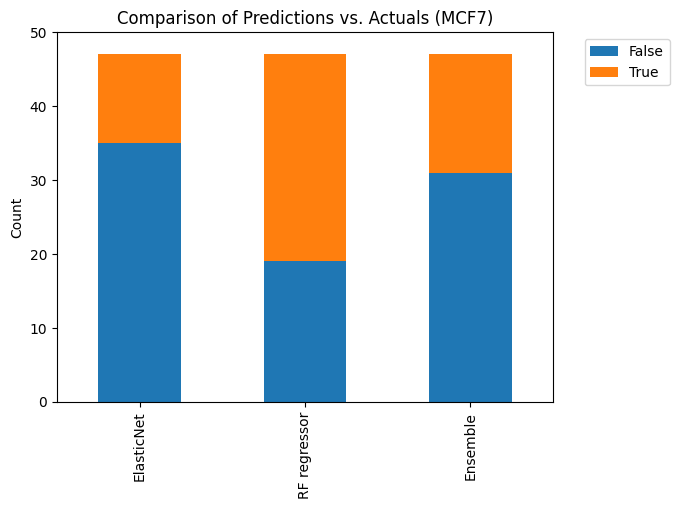

In [45]:
#MCF7
get_pred_vs_actual_comparison(df_elastic = mcf7_pred_elastic_filtered_mean,
                              df_rf = mcf7_pred_rf_filtered_mean,
                              df_ensemble = mcf7_pred_ensemble_filtered_mean,
                              df_lcms = mcf7_lcms_filtered_mean,
                              cell_line_name = 'MCF7')

Correctly predicted metabolites from Elastic Net: ['citrulline', 'alpha-ketoglutarate', 'lysine', 'malate', 'creatinine', 'fumarate/maleate/alpha-ketoisovalerate', 'phenylalanine', 'UMP', 'xanthine', 'creatine', 'histidine', 'NAD', 'alanine', 'threonine', 'leucine', 'phosphocreatine', 'urate', 'serine', 'glutamine', 'homocysteine', 'succinate/methylmalonate', 'betaine', 'ornithine', 'valine', 'arginine', 'asparagine', 'aspartate', 'GABA', 'uracil', 'tyrosine']
Correctly predicted metabolites from Random forest regressor: ['AMP', 'creatinine', 'phenylalanine', 'UMP', 'creatine', 'NAD', 'alanine', 'uridine', 'phosphocreatine', 'urate', 'glutamine', 'proline', 'adenine', 'homocysteine', 'asparagine', 'methionine', 'aspartate', 'GABA']
Correctly predicted metabolites from Ensemble: ['citrulline', 'alpha-ketoglutarate', 'lysine', 'creatinine', 'phenylalanine', 'UMP', 'xanthine', 'taurine', 'creatine', 'histidine', 'NAD', 'alanine', 'threonine', 'leucine', 'phosphocreatine', 'urate', 'serine

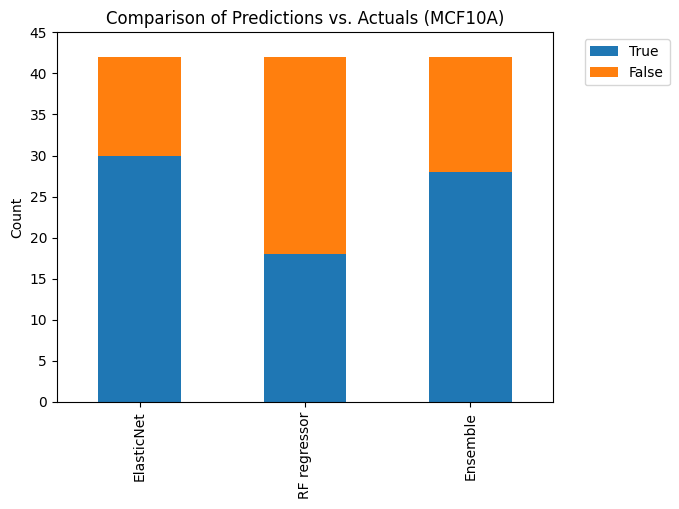

In [46]:
#MCF10A
get_pred_vs_actual_comparison(df_elastic = mcf10a_pred_elastic_filtered_mean,
                              df_rf = mcf10a_pred_rf_filtered_mean,
                              df_ensemble = mcf10a_pred_ensemble_filtered_mean,
                              df_lcms = mcf10a_lcms_filtered_mean,
                              cell_line_name = 'MCF10A')

In [47]:
mcf7_correct_metabolites = ['histidine', 'citrulline', 'glycodeoxycholate/glycochenodeoxycholate', 'valine', 'urate', 'phenylalanine', 'threonine', 'lysine', 'asparagine', 'fumarate/maleate/alpha-ketoisovalerate', 'creatinine', 'homocysteine', 'aspartate', 'glutathione oxidized', 'GABA', 'ornithine', 'methionine', 'tyrosine', 'succinate/methylmalonate', 'arginine', 'uracil', 'UMP', 'NAD', 'serine', 'glutamine', 'allantoin', 'glycine', 'leucine', 'uridine', 'malate', 'creatine', 'thymine', 'phosphocreatine', 'xanthine', 'cystathionine']
mcf10a_correct_metabolites = ['betaine', 'histidine', 'citrulline', 'valine', 'urate', 'phenylalanine', 'threonine', 'lysine', 'asparagine', 'fumarate/maleate/alpha-ketoisovalerate', 'creatinine', 'homocysteine', 'aspartate', 'GABA', 'ornithine', 'tyrosine', 'succinate/methylmalonate', 'arginine', 'uracil', 'UMP', 'NAD', 'serine', 'glutamine', 'alpha-ketoglutarate', 'leucine', 'malate', 'creatine', 'xanthine', 'phosphocreatine', 'alanine']

In [48]:
!pip install matplotlib-venn

In [49]:
from matplotlib_venn import venn2

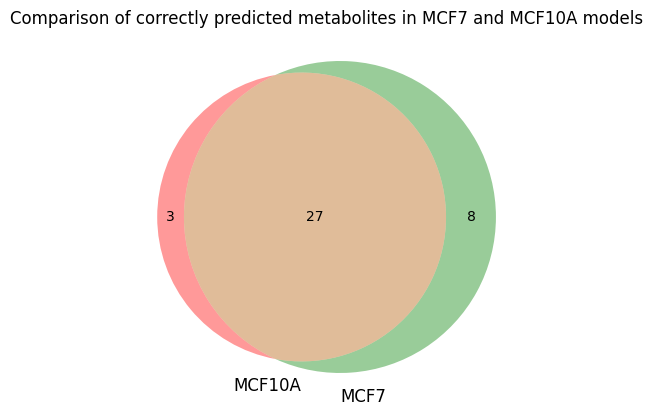

In [50]:
venn2([set(mcf10a_correct_metabolites), set(mcf7_correct_metabolites)], set_labels=('MCF10A', 'MCF7'))
plt.title('Comparison of correctly predicted metabolites in MCF7 and MCF10A models')
plt.savefig('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/MCF10A_MCF7_common_correct_metabolites_venn.svg', bbox_inches = 'tight')
plt.show()

In [51]:
correct_common = list(set(mcf7_correct_metabolites).intersection(set(mcf10a_correct_metabolites)))
correct_common

['citrulline',
 'lysine',
 'malate',
 'creatinine',
 'fumarate/maleate/alpha-ketoisovalerate',
 'phenylalanine',
 'UMP',
 'xanthine',
 'creatine',
 'histidine',
 'NAD',
 'threonine',
 'leucine',
 'phosphocreatine',
 'urate',
 'serine',
 'glutamine',
 'homocysteine',
 'succinate/methylmalonate',
 'ornithine',
 'valine',
 'arginine',
 'asparagine',
 'aspartate',
 'GABA',
 'uracil',
 'tyrosine']

In [52]:
with open('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/MCF10A_MCF7_correct_common_metabolites.txt', 'w') as f:
    for item in correct_common:
      f.write("%s\n" % item)

#LCMS statistics and further plots

In [53]:
from scipy.stats import ttest_ind

In [54]:
def get_statistically_significant_metabolites(df, df_mean, pval_threshold):
  grouped = df.groupby('PI3K_status')
  mut = grouped.get_group('MUT').drop(columns=['PI3K_status'])
  wt = grouped.get_group('WT').drop(columns=['PI3K_status'])
  results = {}
  for col in mut.columns:
    t_stat, p_value = ttest_ind(mut[col], wt[col])
    results[col] = {'T-statistic': t_stat, 'P-value': p_value}
  results_df = pd.DataFrame(results).T
  results_df.index = mut.columns
  df_mean = df_mean.copy()
  df_mean.index.name = None
  res = pd.concat([df_mean, results_df], axis = 'columns')
  return res

In [55]:
mcf7_sig = get_statistically_significant_metabolites(df = mcf7_lcms_filtered, df_mean = mcf7_lcms_filtered_mean,  pval_threshold = 0.05)
mcf7_sig.head(2)

,MUT,WT,Higher_in_MUT,T-statistic,P-value
citrulline,55983.943322,31276.930072,yes,2.868077,0.020891
alpha-ketoglutarate,2334.881654,6646.539171,no,-3.071956,0.015302


In [56]:
mcf10a_sig = get_statistically_significant_metabolites(df = mcf10a_lcms_filtered, df_mean = mcf10a_lcms_filtered_mean,  pval_threshold = 0.05)
mcf10a_sig.head(2)

,MUT,WT,Higher_in_MUT,T-statistic,P-value
citrulline,7826.828872,17890.164990,no,-2.603527,0.021859
alpha-ketoglutarate,5377.358744,7792.504223,no,-1.069312,0.304383


In [57]:
def get_log2fc(df):
  df_res = df
  df_res['log2FC'] = np.log2(df_res['WT'] / df_res['MUT'])
  return   df_res

In [58]:
mf10a_log2fc = get_log2fc(mcf10a_sig)
mf7_log2fc = get_log2fc(mcf7_sig)

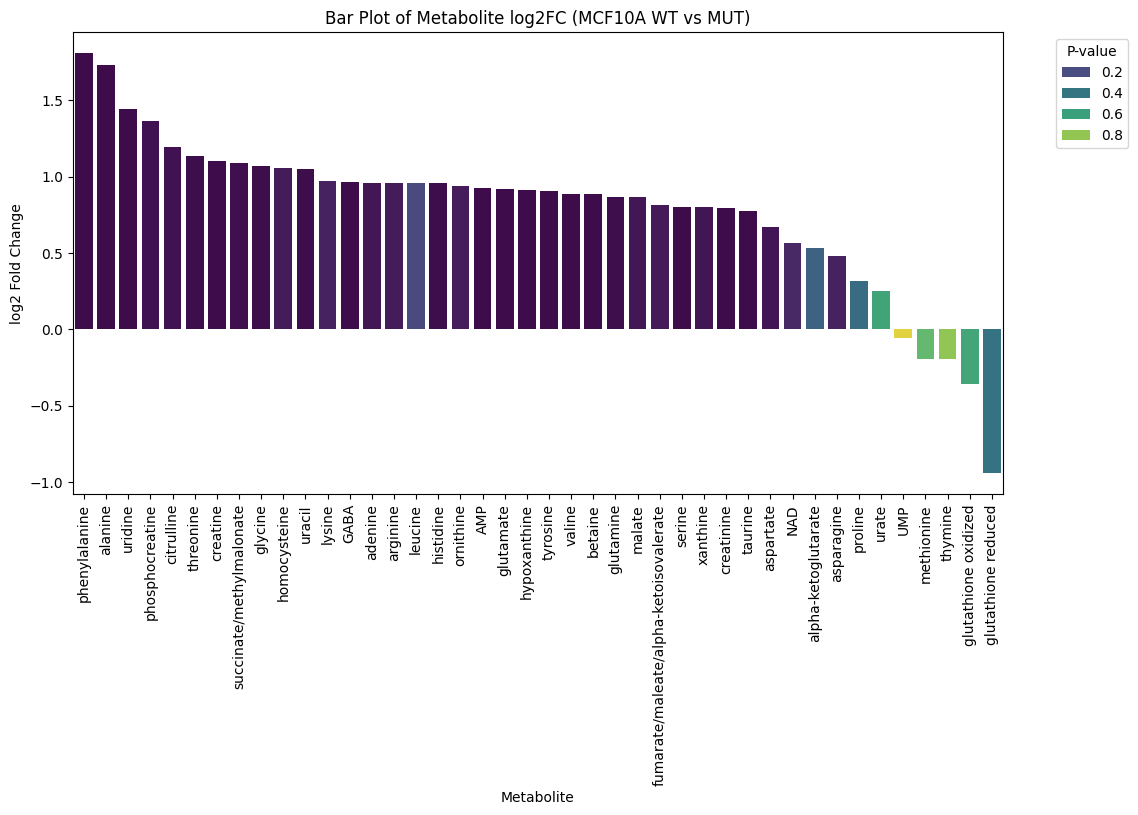

In [59]:
mf10a_log2fc_sorted = mf10a_log2fc.sort_values(by=['log2FC'], ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=mf10a_log2fc_sorted, x=mf10a_log2fc_sorted.index, y='log2FC',
            hue='P-value', palette='viridis', dodge=False)

# Customize the plot
plt.title('Bar Plot of Metabolite log2FC (MCF10A WT vs MUT)')
plt.xlabel('Metabolite')
plt.ylabel('log2 Fold Change')
plt.xticks(rotation=90)
plt.legend(title='P-value', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

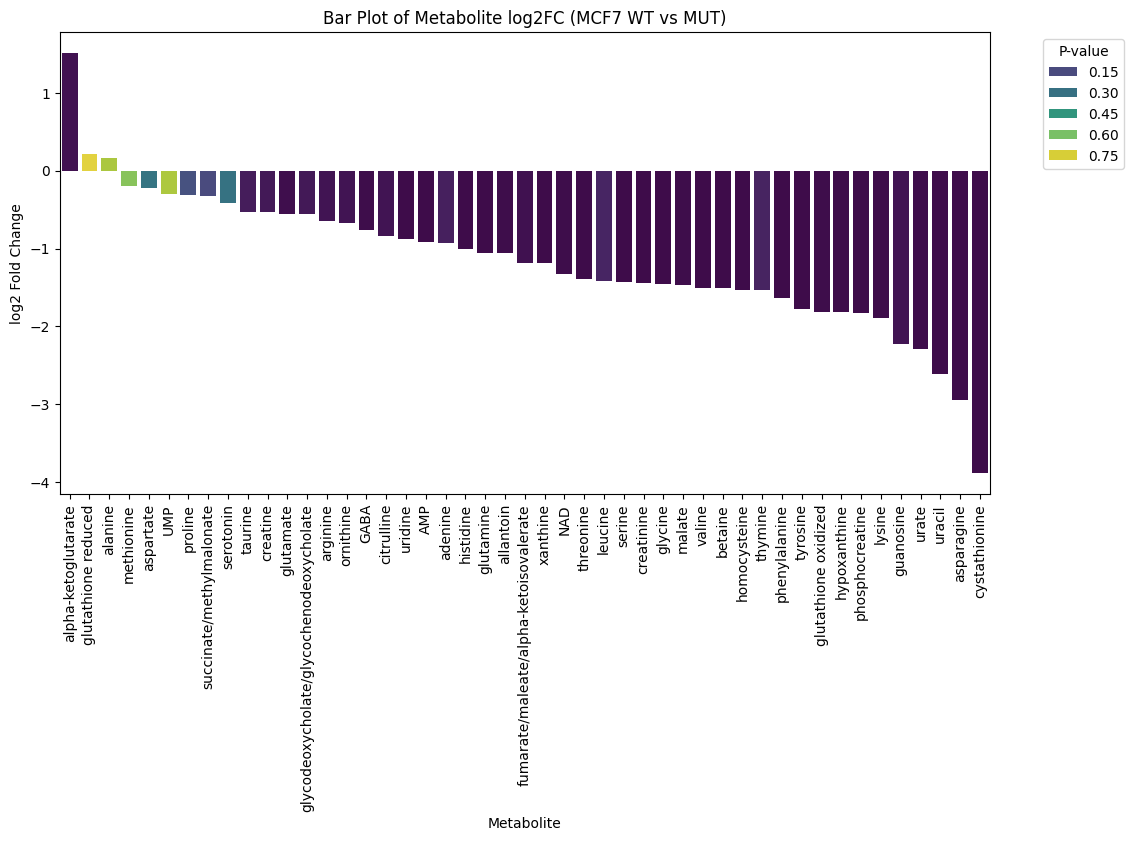

In [60]:
mf7_log2fc_sorted = mf7_log2fc.sort_values(by=['log2FC'], ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=mf7_log2fc_sorted, x=mf7_log2fc_sorted.index, y='log2FC',
            hue='P-value', palette='viridis', dodge=False)

plt.title('Bar Plot of Metabolite log2FC (MCF7 WT vs MUT)')
plt.xlabel('Metabolite')
plt.ylabel('log2 Fold Change')
plt.xticks(rotation=90)
plt.legend(title='P-value', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [61]:
combined = pd.concat([mf7_log2fc_sorted.rename(columns = {'P-value' : 'mcf7_pval', 'log2FC' : 'mcf7_log2FC'})[['mcf7_pval', 'mcf7_log2FC']],
                      mf10a_log2fc_sorted.rename(columns = {'P-value' : 'mcf10a_pval', 'log2FC' : 'mcf10a_log2FC'})[['mcf10a_pval', 'mcf10a_log2FC']]],
                      axis = 'columns')
combined

,mcf7_pval,mcf7_log2FC,mcf10a_pval,mcf10a_log2FC
alpha-ketoglutarate,1.530245e-02,1.509254,0.304383,0.535189
glutathione reduced,7.670783e-01,0.214818,0.393688,-0.942150
alanine,6.850155e-01,0.156065,0.000993,1.730949
methionine,6.267785e-01,-0.194758,0.699416,-0.193511
aspartate,3.190672e-01,-0.229210,0.029227,0.667685
UMP,6.872649e-01,-0.299847,0.951151,-0.057199
proline,1.768200e-01,-0.315509,0.353612,0.317221
succinate/methylmalonate,1.517254e-01,-0.324843,0.014558,1.089788
serotonin,3.135997e-01,-0.409902,NaN,NaN
taurine,3.873264e-02,-0.529283,0.001712,0.772626


In [62]:
combined = combined.dropna()
combined = combined[(combined['mcf7_pval'] < 0.05) & (combined['mcf10a_pval'] < 0.05)]
combined

,mcf7_pval,mcf7_log2FC,mcf10a_pval,mcf10a_log2FC
taurine,0.038733,-0.529283,0.001712,0.772626
creatine,0.029302,-0.536742,0.000890,1.106026
glutamate,0.008413,-0.552661,0.002635,0.917773
arginine,0.019766,-0.640388,0.041001,0.961076
ornithine,0.018790,-0.676924,0.045235,0.937550
GABA,0.003572,-0.757233,0.003596,0.964366
citrulline,0.020891,-0.839914,0.021859,1.192667
uridine,0.000142,-0.873177,0.000724,1.440760
AMP,0.001016,-0.911333,0.002200,0.927946
adenine,0.042862,-0.923150,0.031048,0.961593


In [63]:
combined_heatmap_data = combined.rename(columns = {'mcf7_log2FC': 'MCF7', 'mcf10a_log2FC': 'MCF10A'})[['MCF7', 'MCF10A']]
combined_heatmap_data

,MCF7,MCF10A
taurine,-0.529283,0.772626
creatine,-0.536742,1.106026
glutamate,-0.552661,0.917773
arginine,-0.640388,0.961076
ornithine,-0.676924,0.937550
GABA,-0.757233,0.964366
citrulline,-0.839914,1.192667
uridine,-0.873177,1.440760
AMP,-0.911333,0.927946
adenine,-0.923150,0.961593


<Axes: title={'center': 'log2FC (WT vs MUT) of altered metabolites (LCMS, p-value < 0.05)'}>

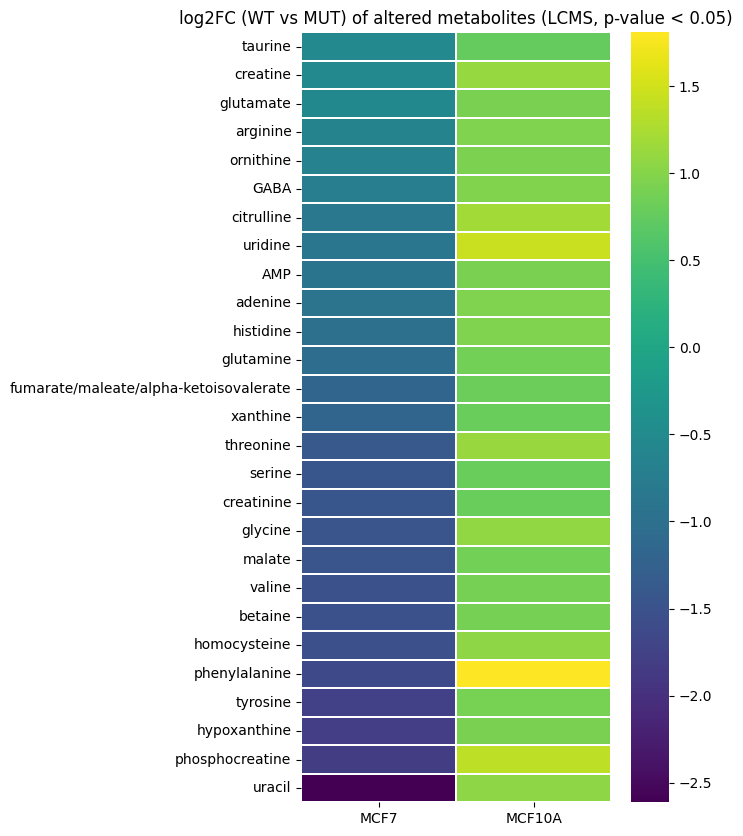

In [64]:
plt.figure(figsize=(5, 10))
plt.title('log2FC (WT vs MUT) of altered metabolites (LCMS, p-value < 0.05)')
sns.heatmap(data = combined_heatmap_data, linewidths = 0.01, cmap = 'viridis')

In [65]:
combination = list(set(correct_common).intersection(set(list(combined_heatmap_data.index))))
(len(combination) * 100/ len(correct_common))

70.37037037037037

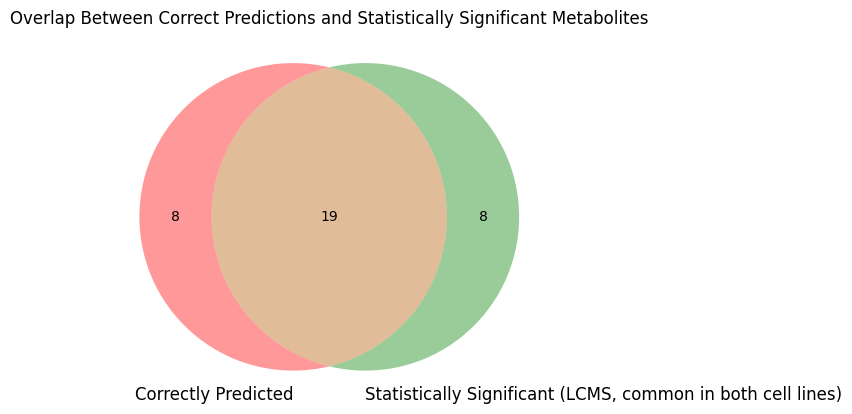

In [66]:
set1 = set(correct_common)
set2 = set(list(combined_heatmap_data.index))

venn2([set1, set2], set_labels=('Correctly Predicted', 'Statistically Significant (LCMS, common in both cell lines)'))
plt.title('Overlap Between Correct Predictions and Statistically Significant Metabolites')
plt.show()

Correctly predicted metabolites from Elastic Net: []
Correctly predicted metabolites from Random forest regressor: ['citrulline', 'creatinine', 'xanthine', 'creatine', 'histidine', 'threonine', 'phosphocreatine', 'serine', 'glutamine', 'ornithine', 'valine', 'tyrosine']
Correctly predicted metabolites from Ensemble: ['malate', 'fumarate/maleate/alpha-ketoisovalerate', 'creatine', 'phosphocreatine', 'homocysteine', 'arginine']


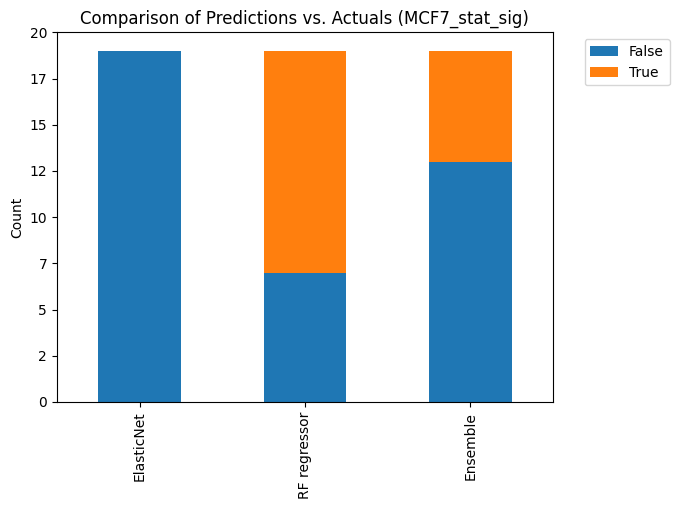

In [67]:
#MCF7
get_pred_vs_actual_comparison(df_elastic = mcf7_pred_elastic_filtered_mean.loc[combination],
                              df_rf = mcf7_pred_rf_filtered_mean.loc[combination],
                              df_ensemble = mcf7_pred_ensemble_filtered_mean.loc[combination],
                              df_lcms = mcf7_lcms_filtered_mean.loc[combination],
                              cell_line_name = 'MCF7_stat_sig')

Correctly predicted metabolites from Elastic Net: ['citrulline', 'malate', 'creatinine', 'fumarate/maleate/alpha-ketoisovalerate', 'phenylalanine', 'xanthine', 'creatine', 'histidine', 'threonine', 'phosphocreatine', 'serine', 'glutamine', 'homocysteine', 'ornithine', 'valine', 'arginine', 'GABA', 'uracil', 'tyrosine']
Correctly predicted metabolites from Random forest regressor: ['creatinine', 'phenylalanine', 'creatine', 'phosphocreatine', 'glutamine', 'homocysteine', 'GABA']
Correctly predicted metabolites from Ensemble: ['citrulline', 'creatinine', 'phenylalanine', 'xanthine', 'creatine', 'histidine', 'threonine', 'phosphocreatine', 'serine', 'ornithine', 'valine', 'GABA', 'uracil', 'tyrosine']


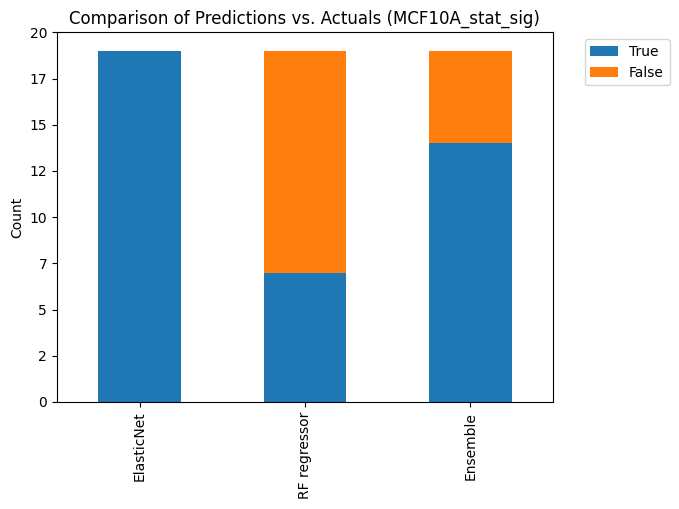

In [68]:
#MCF10A
get_pred_vs_actual_comparison(df_elastic = mcf10a_pred_elastic_filtered_mean.loc[combination],
                              df_rf = mcf10a_pred_rf_filtered_mean.loc[combination],
                              df_ensemble = mcf10a_pred_ensemble_filtered_mean.loc[combination],
                              df_lcms = mcf10a_lcms_filtered_mean.loc[combination],
                              cell_line_name = 'MCF10A_stat_sig')